<a href="https://colab.research.google.com/github/nicolastibata/MINE_4206_AML_202610/blob/main/labs/lab_2/MINE_4206_AML_202610_L2_S3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![Logo AML](https://github.com/nicolastibata/MINE_4206_AML_202610/blob/main/docs/logo.jpg?raw=true)

# **Laboratorio 2 - Sesión 3: Árboles y Random Forest**
**Tutor: Nicolás Tibatá**

## **Tabla de Contenido**

[Contexto y objetivos](#scrollTo=kgcjzQ76ODRS)<br>
[1. Introducción de los datos](#scrollTo=2dNwUTBZO8OE)<br>
[2. Preparación y Modelamiento](#scrollTo=SlV42CI6PBoQ)<br>
[3. Preguntas](#scrollTo=OCwUBTvxPRdS)<br>

### **Contexto y Objetivos**

Este dataset incluye datos para la estimación de los niveles de obesidad en individuos de México, Perú y Colombia, basándose en sus hábitos alimenticios y condición física. Los datos contienen 17 atributos y 2111 registros, etiquetados con la variable de clase Obesity (Nivel de Obesidad), que permite clasificar los datos usando los valores de Peso Insuficiente, Peso Normal, Sobrepeso Nivel I, Sobrepeso Nivel II, Obesidad Tipo I, Obesidad Tipo II y Obesidad Tipo III.

En este problema se busca predecir el nivel de obesidad de un individuo utilizando sus hábitos alimenticios y características físicas para identificar patrones clave.

- Clasificar el nivel de obesidad.
- Definir las variables más importantes para su clasificación.

**Datos:** [Obesity Prediction Dataset](https://www.kaggle.com/datasets/ruchikakumbhar/obesity-prediction)

**Diccionario**

| Atributo       | Descripción                                                                 |
|----------------|-----------------------------------------------------------------------------|
| Gender         | Género                                                                     |
| Age            | Edad                                                                       |
| Height         | Altura en metros                                                           |
| Weight         | Peso en kgs                                                                |
| family_history | ¿Algún familiar ha sufrido o sufre de sobrepeso?                          |
| FAVC           | ¿Consumes alimentos altos en calorías frecuentemente?                      |
| FCVC           | ¿Sueles comer vegetales en tus comidas?                                    |
| NCP            | ¿Cuántas comidas principales haces al día?                                 |
| CAEC           | ¿Comes algo entre comidas?                                                 |
| SMOKE          | ¿Fumas?                                                                    |
| CH2O           | ¿Cuánta agua bebes al día?                                                 |
| SCC            | ¿Controlas las calorías que consumes diariamente?                          |
| FAF            | ¿Con qué frecuencia realizas actividad física?                             |
| TUE            | ¿Cuánto tiempo usas dispositivos tecnológicos como celular, videojuegos, televisión, computadora y otros? |
| CALC           | ¿Con qué frecuencia consumes alcohol?                                      |
| MTRANS         | ¿Qué transporte utilizas habitualmente?                                    |
| Obesity  | Nivel de Obesidad (Target Variable)                                       |

### **1. Introducción a los datos**

In [ ]:
# Importamos o instalamos librerias necesarias
!pip install ydata-profiling -q
from ydata_profiling import ProfileReport
# Acceso a credenciales
import os
from google.colab import files
from google.colab import userdata
# Manejo de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Modelamiento
import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV, train_test_split, validation_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer,  OneHotEncoder, OrdinalEncoder, MinMaxScaler, StandardScaler, label_binarize
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, roc_curve, auc, roc_auc_score
#Librerías extras
import itertools
from datetime import datetime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.8/65.8 kB 4.4 MB/s eta 0:00:00


Cargamos los datos directamente de kaggle con las credenciales personales, pueden consultar cómo funciona [acá](https://www.kaggle.com/discussions/general/74235#2580958).

In [ ]:
os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')

!kaggle datasets download -d ruchikakumbhar/obesity-prediction
!unzip "obesity-prediction.zip"

Dataset URL: https://www.kaggle.com/datasets/ruchikakumbhar/obesity-prediction
License(s): Attribution 4.0 International (CC BY 4.0)
  0% 0.00/57.5k [00:00<?, ?B/s]
100% 57.5k/57.5k [00:00<00:00, 128MB/s]
Archive:  obesity-prediction.zip
  inflating: Obesity prediction.csv  


In [ ]:
data = pd.read_csv('Obesity prediction.csv')
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   object 
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   object 
 5   FAVC            2111 non-null   object 
 6   FCVC            2111 non-null   float64
 7   NCP             2111 non-null   float64
 8   CAEC            2111 non-null   object 
 9   SMOKE           2111 non-null   object 
 10  CH2O            2111 non-null   float64
 11  SCC             2111 non-null   object 
 12  FAF             2111 non-null   float64
 13  TUE             2111 non-null   float64
 14  CALC            2111 non-null   object 
 15  MTRANS          2111 non-null   object 
 16  Obesity         2111 non-null   object 
dtypes: float64(8), object(9)
memory u

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [ ]:
data

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


### **2. Preparación y Modelamiento**

Antes de preparar y modelar los datos, veamos un poco cómo se constituyen

In [ ]:
ProfileReport(data)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 17/17 [00:00<00:00, 17.89it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Hallazgos:
- Nuestra variable Target `Obesity` no presenta un desbalance de clases significativo, sin embargo usaremos un `stratify` en la separación de los datos de train y test.
- Las variables numéricas presentan una escala de sus datos significativa, sin embargo al usar modelos basados en árboles la magnitud de las variables no es un problema.
- Las variables categoricas requieren de `onehotencoder` para su codificación.
- No hay presencia de correlación considerable entre las variables.

#### **Preparación**

In [ ]:
# 1. Separar los datos en entrenamiento y test -> SIEMPRE
train_data, test_data = train_test_split(data, test_size=0.2, random_state=71, stratify=data['Obesity'])

In [ ]:
drop_variables = []
target_feature = 'Obesity'

def preprocess(df):
  print(f"Total de filas duplicadas eliminadas: {df.duplicated().sum().sum()}\n")
  df = df.drop_duplicates() # Eliminamos duplicados si existen
  df = df.drop(drop_variables, axis = 1) # Eliminamos columnas que no vamos a usar si existen
  X_data, y_variable = df.drop([target_feature], axis=1), df[target_feature] # Separamos nuestro target de las variables explicativas
  return X_data, y_variable


In [ ]:
X_train, y_train = preprocess(train_data)
display(X_train)
display(y_train)

Total de filas duplicadas eliminadas: 16



,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS
902,Female,38.939448,1.738321,86.934846,no,yes,2.843709,3.058539,Sometimes,no,1.130079,no,2.834373,0.044954,Sometimes,Automobile
1644,Male,27.474245,1.843420,120.420406,yes,yes,2.765063,3.000000,Sometimes,no,2.867206,no,0.706777,0.677909,Sometimes,Public_Transportation
2058,Female,26.000000,1.640745,110.919646,yes,yes,3.000000,3.000000,Sometimes,no,2.666178,no,0.000000,0.276907,Sometimes,Public_Transportation
2040,Female,25.982261,1.629225,104.838425,yes,yes,3.000000,3.000000,Sometimes,no,2.556068,no,0.016820,0.582840,Sometimes,Public_Transportation
918,Female,21.996118,1.730199,78.997062,yes,yes,2.277077,1.000000,Sometimes,no,2.000000,no,1.061743,0.000000,Sometimes,Public_Transportation
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1384,Female,24.565628,1.620930,81.718232,yes,yes,2.260543,1.374791,Sometimes,no,1.947935,no,0.000000,0.078607,no,Public_Transportation
559,Male,19.920629,1.768493,57.790381,yes,yes,2.000000,3.897078,Sometimes,no,2.622638,no,2.000000,1.894105,no,Automobile
1104,Female,38.384177,1.698626,78.637307,yes,yes,3.000000,3.000000,Sometimes,no,2.503198,no,0.000000,0.000000,no,Automobile
865,Female,18.000000,1.456346,55.523481,no,yes,2.000000,3.000000,Sometimes,no,1.040342,yes,0.497373,1.783319,Sometimes,Public_Transportation


,Obesity
902,Overweight_Level_I
1644,Obesity_Type_II
2058,Obesity_Type_III
2040,Obesity_Type_III
918,Overweight_Level_I
...,...
1384,Obesity_Type_I
559,Insufficient_Weight
1104,Overweight_Level_II
865,Overweight_Level_I


In [ ]:
# Definamos las variables numericas
num_features = X_train.select_dtypes(include=['int64', 'float64']).columns
print(num_features)
cat_features = X_train.select_dtypes(include=['object']).columns
print(cat_features)

Index(['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE'], dtype='object')
Index(['Gender', 'family_history', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC',
       'MTRANS'],
      dtype='object')


In [ ]:
# Construimos y aplicamos nuestro pipeline
num_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median'))
    ]
)

cat_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),  # moda
        ('scaler', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        #('num', num_transformer, make_column_selector(dtype_include=np.number)),
        ('num', num_transformer, num_features),
        #('cat', cat_transformer, make_column_selector(dtype_include=object))
        ('cat', cat_transformer, cat_features)
    ]
).set_output(transform="pandas") #Para preservar los nombres de las columnas

pipe = Pipeline(steps=[('column_transformer', preprocessor)])

In [ ]:
pipe.fit_transform(X_train)

,num__Age,num__Height,num__Weight,num__FCVC,num__NCP,num__CH2O,num__FAF,num__TUE,cat__Gender_Female,cat__Gender_Male,...,cat__SCC_yes,cat__CALC_Always,cat__CALC_Frequently,cat__CALC_Sometimes,cat__CALC_no,cat__MTRANS_Automobile,cat__MTRANS_Bike,cat__MTRANS_Motorbike,cat__MTRANS_Public_Transportation,cat__MTRANS_Walking
902,38.939448,1.738321,86.934846,2.843709,3.058539,1.130079,2.834373,0.044954,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1644,27.474245,1.843420,120.420406,2.765063,3.000000,2.867206,0.706777,0.677909,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2058,26.000000,1.640745,110.919646,3.000000,3.000000,2.666178,0.000000,0.276907,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2040,25.982261,1.629225,104.838425,3.000000,3.000000,2.556068,0.016820,0.582840,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
918,21.996118,1.730199,78.997062,2.277077,1.000000,2.000000,1.061743,0.000000,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1384,24.565628,1.620930,81.718232,2.260543,1.374791,1.947935,0.000000,0.078607,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
559,19.920629,1.768493,57.790381,2.000000,3.897078,2.622638,2.000000,1.894105,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
1104,38.384177,1.698626,78.637307,3.000000,3.000000,2.503198,0.000000,0.000000,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
865,18.000000,1.456346,55.523481,2.000000,3.000000,1.040342,0.497373,1.783319,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
cat_column_names = pipe['column_transformer'].transformers_[1][1][1].get_feature_names_out()
num_column_names = pipe['column_transformer'].transformers_[0][1].feature_names_in_
col_names = list(num_column_names) + list(cat_column_names)

col_names

['Age',
 'Height',
 'Weight',
 'FCVC',
 'NCP',
 'CH2O',
 'FAF',
 'TUE',
 'Gender_Female',
 'Gender_Male',
 'family_history_no',
 'family_history_yes',
 'FAVC_no',
 'FAVC_yes',
 'CAEC_Always',
 'CAEC_Frequently',
 'CAEC_Sometimes',
 'CAEC_no',
 'SMOKE_no',
 'SMOKE_yes',
 'SCC_no',
 'SCC_yes',
 'CALC_Always',
 'CALC_Frequently',
 'CALC_Sometimes',
 'CALC_no',
 'MTRANS_Automobile',
 'MTRANS_Bike',
 'MTRANS_Motorbike',
 'MTRANS_Public_Transportation',
 'MTRANS_Walking']

In [ ]:
pd.DataFrame(pipe.fit_transform(X_train))

,num__Age,num__Height,num__Weight,num__FCVC,num__NCP,num__CH2O,num__FAF,num__TUE,cat__Gender_Female,cat__Gender_Male,...,cat__SCC_yes,cat__CALC_Always,cat__CALC_Frequently,cat__CALC_Sometimes,cat__CALC_no,cat__MTRANS_Automobile,cat__MTRANS_Bike,cat__MTRANS_Motorbike,cat__MTRANS_Public_Transportation,cat__MTRANS_Walking
902,38.939448,1.738321,86.934846,2.843709,3.058539,1.130079,2.834373,0.044954,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1644,27.474245,1.843420,120.420406,2.765063,3.000000,2.867206,0.706777,0.677909,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2058,26.000000,1.640745,110.919646,3.000000,3.000000,2.666178,0.000000,0.276907,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2040,25.982261,1.629225,104.838425,3.000000,3.000000,2.556068,0.016820,0.582840,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
918,21.996118,1.730199,78.997062,2.277077,1.000000,2.000000,1.061743,0.000000,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1384,24.565628,1.620930,81.718232,2.260543,1.374791,1.947935,0.000000,0.078607,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
559,19.920629,1.768493,57.790381,2.000000,3.897078,2.622638,2.000000,1.894105,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
1104,38.384177,1.698626,78.637307,3.000000,3.000000,2.503198,0.000000,0.000000,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
865,18.000000,1.456346,55.523481,2.000000,3.000000,1.040342,0.497373,1.783319,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


#### **Modelamiento**

##### **Modelo: Árboles**

In [ ]:
# Creamos el pipe para random forest
estimators_dt = [
    ('transform', preprocessor),
    ('model', DecisionTreeClassifier(max_depth=3, random_state=71))
]

pipe_dt = Pipeline(estimators_dt)
pipe_dt

Pipeline(steps=[('transform',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('scaler',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Gender', 'family_history', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC',
       'MTRANS'],
      dtype='object'))])),
                ('model',
                 DecisionTreeClassifier(max_depth=3, random_state=71))])

In [ ]:
%time
pipe_dt.fit(X_train, y_train)

CPU times: user 5 µs, sys: 0 ns, total: 5 µs
Wall time: 8.82 µs


Pipeline(steps=[('transform',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('scaler',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Gender', 'family_history', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC',
       'MTRANS'],
      dtype='object'))])),
                ('model',
                 DecisionTreeClassifier(max_depth=3, random_state=71))])

In [ ]:
y_pred_train_dt = pipe_dt.predict(X_train)
y_pred_train_dt

array(['Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', ...,
       'Obesity_Type_I', 'Normal_Weight', 'Obesity_Type_I'], dtype=object)

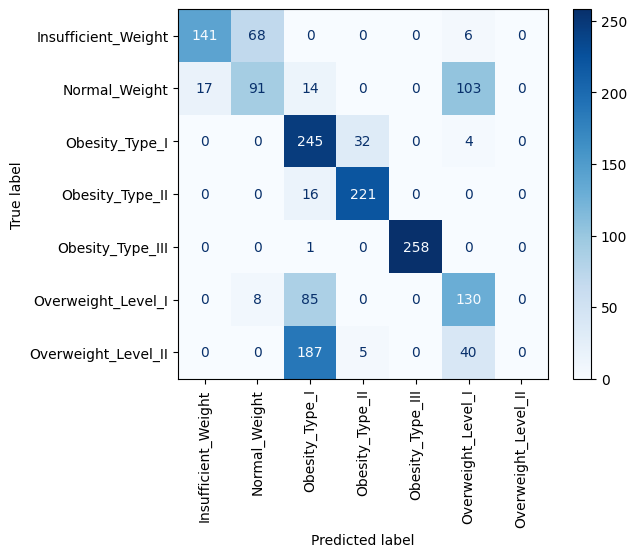

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_train, y_pred_train_dt, cmap='Blues')
plt.xticks(rotation=90)
plt.show()

In [ ]:
# Veamos los rendimientos de nuestro modelo
train_report = classification_report(y_train, y_pred_train_dt)
print("Train Report\n", train_report)

Train Report
                      precision    recall  f1-score   support

Insufficient_Weight       0.89      0.66      0.76       215
      Normal_Weight       0.54      0.40      0.46       225
     Obesity_Type_I       0.45      0.87      0.59       281
    Obesity_Type_II       0.86      0.93      0.89       237
   Obesity_Type_III       1.00      1.00      1.00       259
 Overweight_Level_I       0.46      0.58      0.51       223
Overweight_Level_II       0.00      0.00      0.00       232

           accuracy                           0.65      1672
          macro avg       0.60      0.63      0.60      1672
       weighted avg       0.60      0.65      0.61      1672



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Evaluemos con Test**

In [ ]:
# Antes debemos aplicar la función preprocess y el pipe hace el resto
X_test, y_test = preprocess(test_data)

Total de filas duplicadas eliminadas: 5



In [ ]:
y_pred_test_dt = pipe_dt.predict(X_test)
y_pred_test_dt

array(['Obesity_Type_I', 'Obesity_Type_III', 'Obesity_Type_III',
       'Obesity_Type_III', 'Obesity_Type_III', 'Obesity_Type_I',
       'Normal_Weight', 'Obesity_Type_I', 'Overweight_Level_I',
       'Overweight_Level_I', 'Obesity_Type_III', 'Obesity_Type_I',
       'Overweight_Level_I', 'Overweight_Level_I', 'Obesity_Type_I',
       'Insufficient_Weight', 'Obesity_Type_I', 'Obesity_Type_I',
       'Insufficient_Weight', 'Obesity_Type_II', 'Insufficient_Weight',
       'Insufficient_Weight', 'Obesity_Type_II', 'Obesity_Type_I',
       'Overweight_Level_I', 'Insufficient_Weight', 'Obesity_Type_III',
       'Overweight_Level_I', 'Normal_Weight', 'Overweight_Level_I',
       'Overweight_Level_I', 'Obesity_Type_II', 'Obesity_Type_II',
       'Obesity_Type_II', 'Obesity_Type_I', 'Insufficient_Weight',
       'Obesity_Type_I', 'Obesity_Type_II', 'Normal_Weight',
       'Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_II',
       'Obesity_Type_I', 'Obesity_Type_III', 'Obesity_Type_II',


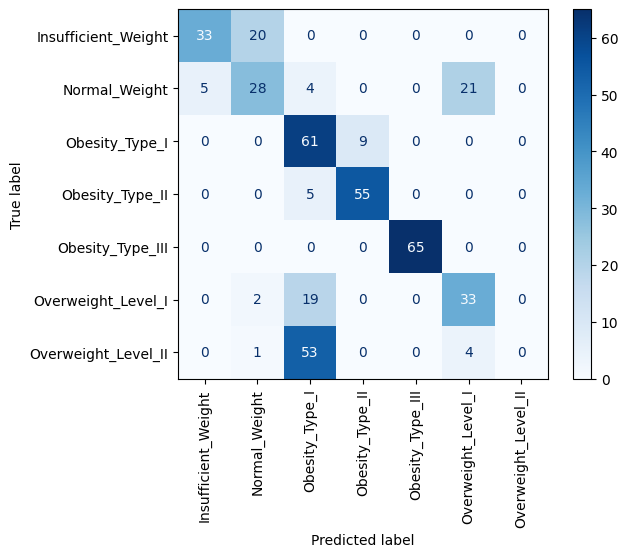

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test_dt, cmap='Blues')
plt.xticks(rotation=90)
plt.show()

In [ ]:
# Veamos los rendimientos de nuestro modelo
train_report = classification_report(y_test, y_pred_test_dt)
print("Train Report\n", train_report)

Train Report
                      precision    recall  f1-score   support

Insufficient_Weight       0.87      0.62      0.73        53
      Normal_Weight       0.55      0.48      0.51        58
     Obesity_Type_I       0.43      0.87      0.58        70
    Obesity_Type_II       0.86      0.92      0.89        60
   Obesity_Type_III       1.00      1.00      1.00        65
 Overweight_Level_I       0.57      0.61      0.59        54
Overweight_Level_II       0.00      0.00      0.00        58

           accuracy                           0.66       418
          macro avg       0.61      0.64      0.61       418
       weighted avg       0.61      0.66      0.62       418



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


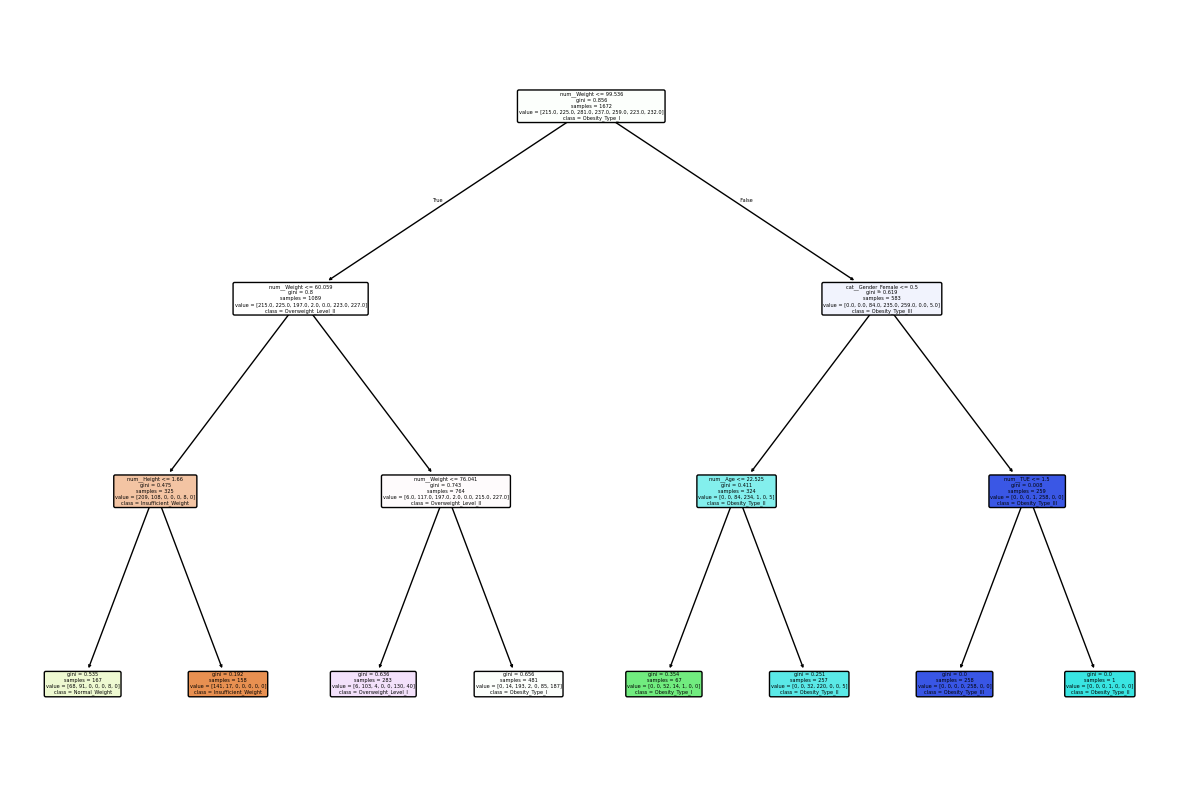

In [ ]:
columns = list(pipe_dt[0].get_feature_names_out())
classes = pipe_dt[1].classes_
first_tree = pipe_dt[1]
plt.figure(figsize=(15, 10))
plot_tree(first_tree, feature_names=columns, class_names=list(map(str, classes)), filled=True, rounded=True)
plt.show()

##### **Modelo: Random Forest**

In [ ]:
# Creamos el pipe para random forest
estimators_rf = [
    ('transform', preprocessor),
    ('model', RandomForestClassifier(n_estimators=10, max_depth=3, random_state=71))
]

pipe_rf = Pipeline(estimators_rf)
pipe_rf

Pipeline(steps=[('transform',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('scaler',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Gender', 'family_history', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC',
       'MTRANS'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(max_depth=3, n_estimators=10,
                                        random_state=71))])

In [ ]:
%time
pipe_rf.fit(X_train, y_train)

CPU times: user 4 µs, sys: 1 µs, total: 5 µs
Wall time: 11.9 µs


Pipeline(steps=[('transform',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('scaler',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Gender', 'family_history', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC',
       'MTRANS'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(max_depth=3, n_estimators=10,
                                        random_state=71))])

In [ ]:
y_pred_train_rf = pipe_rf.predict(X_train)
y_pred_train_rf

array(['Normal_Weight', 'Obesity_Type_II', 'Obesity_Type_III', ...,
       'Obesity_Type_I', 'Overweight_Level_I', 'Obesity_Type_I'],
      dtype=object)

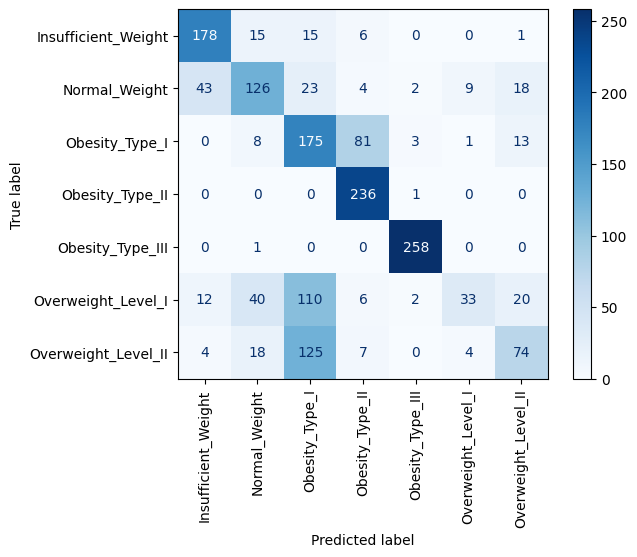

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_train, y_pred_train_rf, cmap='Blues')
plt.xticks(rotation=90)
plt.show()

In [ ]:
# Veamos los rendimientos de nuestro modelo
train_report = classification_report(y_train, y_pred_train_rf)
print("Train Report\n", train_report)

Train Report
                      precision    recall  f1-score   support

Insufficient_Weight       0.75      0.83      0.79       215
      Normal_Weight       0.61      0.56      0.58       225
     Obesity_Type_I       0.39      0.62      0.48       281
    Obesity_Type_II       0.69      1.00      0.82       237
   Obesity_Type_III       0.97      1.00      0.98       259
 Overweight_Level_I       0.70      0.15      0.24       223
Overweight_Level_II       0.59      0.32      0.41       232

           accuracy                           0.65      1672
          macro avg       0.67      0.64      0.62      1672
       weighted avg       0.67      0.65      0.62      1672



**Los resultados son buenos pero no los mejores, realicemos una ligera búsqueda de hiperparámetros**

In [ ]:
param_grid = {
    # Hiperparametros para el modelo
    'model__n_estimators': [10, 20, 30],
    'model__max_depth': [None, 5, 10],
    'model__criterion': ['entropy'],
    # Hiperparametros para el preprocesamiento
    'transform__cat__scaler': [OneHotEncoder()]
}

In [ ]:
grid_search = GridSearchCV(pipe_rf, param_grid, verbose=2, scoring='precision_macro', cv=5, n_jobs=-1)

In [ ]:
%%time
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan]
  warnings.warn(


CPU times: user 427 ms, sys: 40.4 ms, total: 467 ms
Wall time: 16.1 s


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('transform',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median'))]),
                                                                         Index(['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE'], dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('scaler',
                                                                                          OneHotEncoder(handle_unkn...
                                                                         Index(['Gender', 'family_history', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC',
       'MTRANS'],
      dtype='object'))])),
                                       ('model',
                                        RandomForestClassifier(max_depth=3,
                                                               n_estimators=10,
                                                               random_state=71))]),
             n_jobs=-1,
             param_grid={'model__criterion': ['entropy'],
                         'model__max_depth': [None, 5, 10],
                         'model__n_estimators': [10, 20, 30],
                         'transform__cat__scaler': [OneHotEncoder()]},
             scoring='precision_macro', verbose=2)

In [ ]:
pd.DataFrame(grid_search.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__criterion,param_model__max_depth,param_model__n_estimators,param_transform__cat__scaler,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.333262,0.074127,0.125864,0.046532,entropy,None,10,OneHotEncoder(),"{'model__criterion': 'entropy', 'model__max_de...",0.910265,NaN,0.884654,0.912628,0.909553,NaN,NaN,1
1,0.450689,0.027437,0.064307,0.012266,entropy,None,20,OneHotEncoder(),"{'model__criterion': 'entropy', 'model__max_de...",0.897368,NaN,0.917357,0.943477,0.923024,NaN,NaN,1
2,0.397559,0.111242,0.086428,0.063478,entropy,None,30,OneHotEncoder(),"{'model__criterion': 'entropy', 'model__max_de...",0.913918,NaN,0.916392,0.951655,0.934689,NaN,NaN,1
3,0.298414,0.103394,0.072728,0.022033,entropy,5,10,OneHotEncoder(),"{'model__criterion': 'entropy', 'model__max_de...",0.786499,NaN,0.819948,0.757383,0.792267,NaN,NaN,1
4,0.483056,0.016978,0.101651,0.031149,entropy,5,20,OneHotEncoder(),"{'model__criterion': 'entropy', 'model__max_de...",0.803978,NaN,0.831478,0.844096,0.829160,NaN,NaN,1
5,0.484270,0.105555,0.072996,0.038604,entropy,5,30,OneHotEncoder(),"{'model__criterion': 'entropy', 'model__max_de...",0.831127,NaN,0.797909,0.843572,0.836111,NaN,NaN,1
6,0.145517,0.045672,0.044891,0.016287,entropy,10,10,OneHotEncoder(),"{'model__criterion': 'entropy', 'model__max_de...",0.901003,NaN,0.900870,0.902907,0.908506,NaN,NaN,1
7,0.261502,0.048226,0.040097,0.018036,entropy,10,20,OneHotEncoder(),"{'model__criterion': 'entropy', 'model__max_de...",0.915322,NaN,0.920705,0.916718,0.925602,NaN,NaN,1
8,0.402771,0.078374,0.049246,0.018891,entropy,10,30,OneHotEncoder(),"{'model__criterion': 'entropy', 'model__max_de...",0.925461,NaN,0.929522,0.925619,0.941232,NaN,NaN,1


In [ ]:
best_model = grid_search.best_estimator_
grid_search.best_params_

{'model__criterion': 'entropy',
 'model__max_depth': None,
 'model__n_estimators': 10,
 'transform__cat__scaler': OneHotEncoder()}

In [ ]:
y_pred_train_hip = best_model.predict(X_train)
y_pred_train_hip

array(['Overweight_Level_I', 'Obesity_Type_II', 'Obesity_Type_III', ...,
       'Overweight_Level_II', 'Overweight_Level_I', 'Obesity_Type_I'],
      dtype=object)

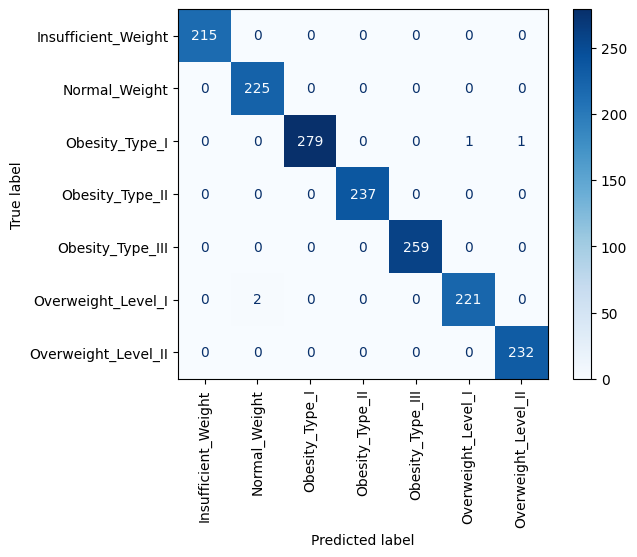

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_train, y_pred_train_hip, cmap='Blues')
plt.xticks(rotation=90)
plt.show()

In [ ]:
# Veamos los rendimientos de nuestro modelo
train_report = classification_report(y_train, y_pred_train_hip)
print("Train Report\n", train_report)

Train Report
                      precision    recall  f1-score   support

Insufficient_Weight       1.00      1.00      1.00       215
      Normal_Weight       0.99      1.00      1.00       225
     Obesity_Type_I       1.00      0.99      1.00       281
    Obesity_Type_II       1.00      1.00      1.00       237
   Obesity_Type_III       1.00      1.00      1.00       259
 Overweight_Level_I       1.00      0.99      0.99       223
Overweight_Level_II       1.00      1.00      1.00       232

           accuracy                           1.00      1672
          macro avg       1.00      1.00      1.00      1672
       weighted avg       1.00      1.00      1.00      1672



###### **Evaluación**
Veamos los resultados con test de nuestro mejor modelo

In [ ]:
# Antes debemos aplicar la función preprocess y el pipe hace el resto
X_test, y_test = preprocess(test_data)

Total de filas duplicadas eliminadas: 5



In [ ]:
y_pred_test_hip = best_model.predict(X_test)
y_pred_test_hip

array(['Obesity_Type_I', 'Obesity_Type_III', 'Obesity_Type_III',
       'Obesity_Type_III', 'Obesity_Type_III', 'Overweight_Level_I',
       'Insufficient_Weight', 'Overweight_Level_II', 'Overweight_Level_I',
       'Normal_Weight', 'Obesity_Type_III', 'Obesity_Type_II',
       'Normal_Weight', 'Overweight_Level_I', 'Normal_Weight',
       'Insufficient_Weight', 'Normal_Weight', 'Overweight_Level_I',
       'Insufficient_Weight', 'Obesity_Type_II', 'Insufficient_Weight',
       'Insufficient_Weight', 'Obesity_Type_II', 'Obesity_Type_I',
       'Overweight_Level_I', 'Insufficient_Weight', 'Obesity_Type_III',
       'Normal_Weight', 'Insufficient_Weight', 'Overweight_Level_I',
       'Overweight_Level_I', 'Obesity_Type_II', 'Obesity_Type_II',
       'Obesity_Type_II', 'Obesity_Type_I', 'Insufficient_Weight',
       'Overweight_Level_II', 'Obesity_Type_II', 'Normal_Weight',
       'Insufficient_Weight', 'Insufficient_Weight', 'Obesity_Type_I',
       'Obesity_Type_I', 'Obesity_Type_III', 

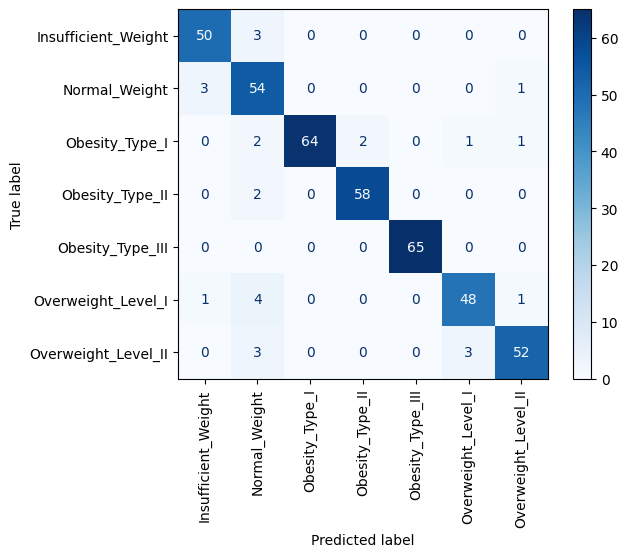

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test_hip, cmap='Blues')
plt.xticks(rotation=90)
plt.show()

In [ ]:
test_report = classification_report(y_test, y_pred_test_hip)
print("Test Report\n", test_report)

Test Report
                      precision    recall  f1-score   support

Insufficient_Weight       0.93      0.94      0.93        53
      Normal_Weight       0.79      0.93      0.86        58
     Obesity_Type_I       1.00      0.91      0.96        70
    Obesity_Type_II       0.97      0.97      0.97        60
   Obesity_Type_III       1.00      1.00      1.00        65
 Overweight_Level_I       0.92      0.89      0.91        54
Overweight_Level_II       0.95      0.90      0.92        58

           accuracy                           0.94       418
          macro avg       0.94      0.93      0.93       418
       weighted avg       0.94      0.94      0.94       418



In [ ]:
columns = list(best_model[0].get_feature_names_out())
importances = best_model[1].feature_importances_

feature_importances = pd.DataFrame({'Feature': columns, 'Importance': importances})
feature_importances.sort_values(by='Importance', ascending=False)

,Feature,Importance
2,num__Weight,0.308761
0,num__Age,0.093773
3,num__FCVC,0.067500
1,num__Height,0.066880
8,cat__Gender_Female,0.052937
4,num__NCP,0.052648
7,num__TUE,0.043478
5,num__CH2O,0.040667
9,cat__Gender_Male,0.039583
11,cat__family_history_yes,0.028925


/tmp/ipykernel_767/3530274774.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  s1.set_xticklabels(s1.get_xticklabels(), rotation=45, ha='right')


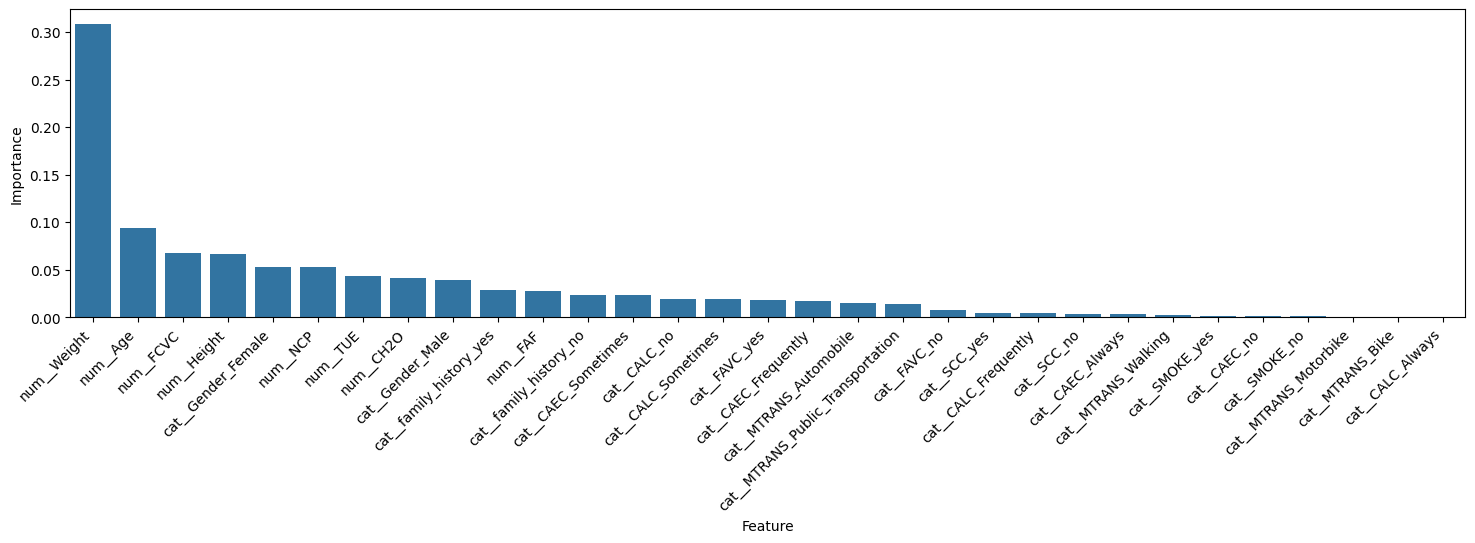

In [ ]:
plt.figure(figsize=(18, 4))
s1=sns.barplot(x='Feature', y='Importance', data=feature_importances.sort_values(by='Importance', ascending=False))
s1.set_xticklabels(s1.get_xticklabels(), rotation=45, ha='right')
plt.show()

In [ ]:
first_tree = best_model[1].estimators_[0]
first_tree

DecisionTreeClassifier(criterion='entropy', max_features='sqrt',
                       random_state=797039723)

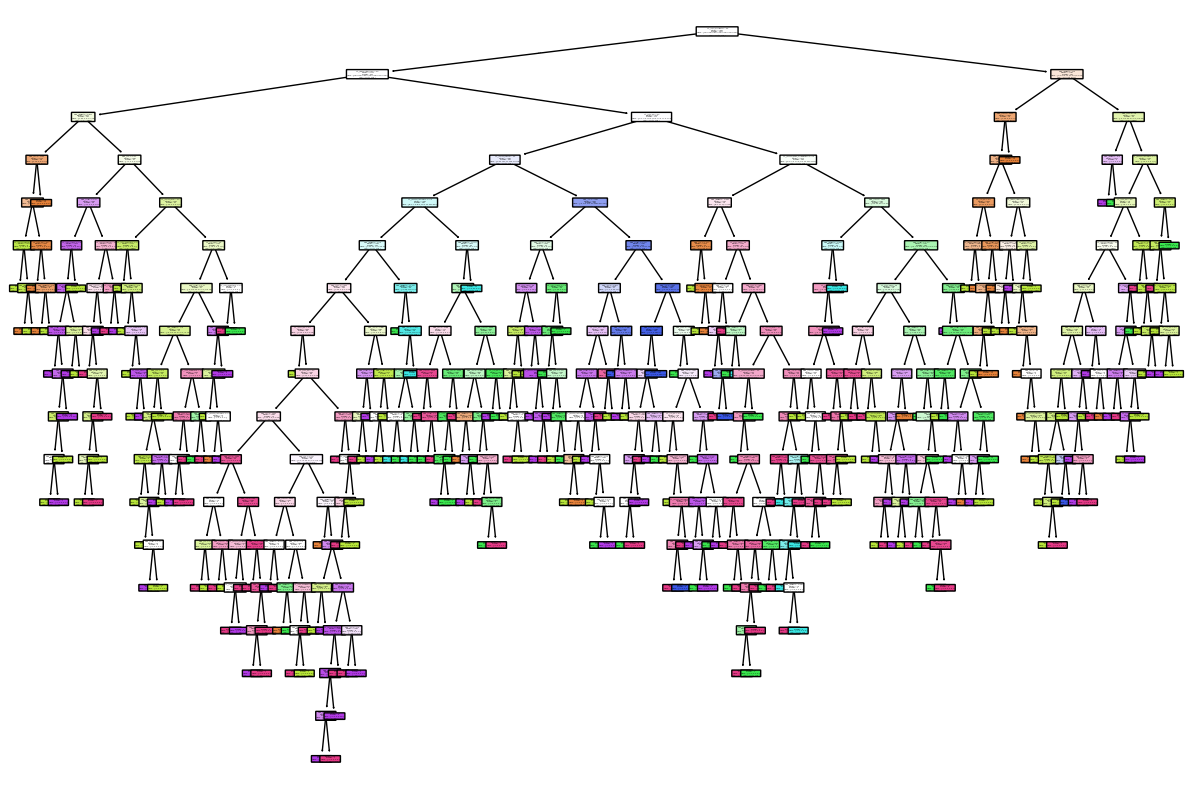

In [ ]:
classes = best_model[1].classes_
plt.figure(figsize=(15, 10))
plot_tree(first_tree, feature_names=columns, class_names=list(map(str, classes)), filled=True, rounded=True)
plt.show()

### **3. Preguntas**

1. Puede haber presencia de overfitting en el mejor modelo? Qué significa `None` en el max_depth?
2. Que pasa si para este ejercicio aplicamos un modelo SVM? Intenta aplicarlo a este dataset.
3. ¿Cómo mejorarías la presentación de los datos de la importancia de las variables?, desde lo funcional e implementado en código.